#### **Memoy**

In [2]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os

if os.environ.get('OPENAI_API_KEY'):
    print('Key is set.')
else:
    raise ValueError('Key is not set in .env file')

llm_model = ChatOpenAI(model='gpt-4-0613')
response = llm_model.invoke('What is the Average Temperature in India')
response.content

Key is set.


'The average temperature in India varies widely depending on the region and season. However, throughout the year, it generally ranges from 25°C to 30°C (77°F to 86°F). Some regions like the Thar desert can reach up to 50°C in summer while in the mountainous regions the temperature can drop below 0°C in winter.'

#### **Create Schema**

In [3]:
from typing import TypedDict, Annotated, List
from langgraph.graph.message import add_messages

class graph_schema(TypedDict):
    message: Annotated[List, add_messages]


#### **Create Nodes**

In [4]:
def know_me(state:graph_schema):
    current_msg = state['message']
    response = llm_model.invoke(current_msg).content
    state['message'] = f'my current message was {current_msg}, LLM generted message is {response}'
    return state

#### **Create Graph**

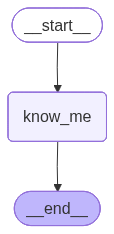

In [8]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import Image

checkpoint = InMemorySaver()

graph = StateGraph(graph_schema)

## Add Nodes
graph.add_node('know_me', know_me)

## Add Edges
graph.add_edge(START, 'know_me')
graph.add_edge('know_me', END)

final_graph = graph.compile(checkpointer=checkpoint)
Image(final_graph.get_graph().draw_mermaid_png())


#### **Test the Memory Graph**

In [20]:
response = final_graph.invoke(
    {'message':'What is my name?'},
    {'configurable':{'thread_id':'AnujAnmolwar'}}
)

for msg in response['message']:
    msg.pretty_print()


================================ Human Message =================================

What is my Name
================================ Human Message =================================

my current message was [HumanMessage(content='What is my Name', additional_kwargs={}, response_metadata={}, id='fef4a901-99b4-4a0c-a702-9e374f96e42a')], LLM generted message is As an artificial intelligence, I am unable to identify your name unless you provide it to me.
================================ Human Message =================================

What is my Name
================================ Human Message =================================

my current message was [HumanMessage(content='What is my Name', additional_kwargs={}, response_metadata={}, id='fef4a901-99b4-4a0c-a702-9e374f96e42a'), HumanMessage(content="my current message was [HumanMessage(content='What is my Name', additional_kwargs={}, response_metadata={}, id='fef4a901-99b4-4a0c-a702-9e374f96e42a')], LLM generted message is As an artificial i